### Load Modeling Data

- Load the final feature list and train/validation/test datasets.
- Load the **2020 stress-test set** for robustness evaluation.
- Separate features (`X`) from the target (`y`) and fill missing values with `0`.
- Define risk labels: **LOW, MODERATE, HIGH**.
- Display feature count, dataset shapes, and training class distribution.

In [1]:
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from time import time

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET       = "next_day_risk_class"
ENG_DIR = Path("../data/training/engineered")
MODEL_Tuning_DIR     = Path("../data/models")
MODEL_Tuning_DIR.mkdir(parents=True , exist_ok=True)
OUT_DIR      = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RISK_LABELS = {0: "LOW", 1: "MODERATE", 2: "HIGH"}
RISK_COLORS = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}

with open(ENG_DIR / "feature_meta.json") as f:
    meta = json.load(f)
FEATURES = meta["final_features"]

train     = pd.read_parquet(ENG_DIR / "train.parquet")
val       = pd.read_parquet(ENG_DIR / "val.parquet")
test      = pd.read_parquet(ENG_DIR / "test.parquet")
stress_20 = pd.read_parquet(ENG_DIR / "stress_2020.parquet")

X_train, y_train = train[FEATURES].fillna(0),     train[TARGET]
X_val,   y_val   = val[FEATURES].fillna(0),       val[TARGET]
X_test,  y_test  = test[FEATURES].fillna(0),      test[TARGET]
X_stress, y_stress = stress_20[FEATURES].fillna(0), stress_20[TARGET]

print(f"Features: {len(FEATURES)}")
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"\nClass distribution (train):")
print((y_train.value_counts(normalize=True)*100).round(1).rename(RISK_LABELS))

Features: 37
Train: (56763, 37)  Val: (15717, 37)  Test: (68581, 37)

Class distribution (train):
next_day_risk_class
LOW         81.0
MODERATE    14.8
HIGH         4.2
Name: proportion, dtype: float64


### Evaluation and Confusion Matrix Helpers

- Define reusable functions to evaluate model performance on different data splits.
- `evaluate()` calculates:
  - Macro F1
  - Balanced accuracy
  - Macro one-vs-rest AUC
  - F1 score for each risk class
  - Full classification report
- `plot_cm()` generates both raw and normalized confusion matrices to examine prediction errors and recall for each risk class.
- Allow custom predictions to be passed to the confusion matrix function for evaluating calibrated predictions later.

In [2]:
def evaluate(name, model, X, y, split="val", proba=None):
    preds = model.predict(X)
    if proba is None:
        proba = model.predict_proba(X) if hasattr(model, "predict_proba") else None
    auc = roc_auc_score(y, proba, multi_class="ovr", average="macro") if proba is not None else float("nan")

    macro_f1  = f1_score(y, preds, average="macro",    zero_division=0)
    bal_acc   = balanced_accuracy_score(y, preds)
    per_class = f1_score(y, preds, average=None,       zero_division=0)

    print(f"\n{'─'*60}")
    print(f"{name}  [{split}]")
    print(f"{'─'*60}")
    print(classification_report(y, preds,
          target_names=[RISK_LABELS[i] for i in range(3)], zero_division=0))
    print(f"Macro F1:        {macro_f1:.4f}")
    print(f"Balanced Acc:    {bal_acc:.4f}")
    print(f"AUC (OvR macro): {auc:.4f}")

    return {
        "name": name, "split": split,
        "macro_f1":    round(macro_f1,    4),
        "balanced_acc":round(bal_acc,     4),
        "auc_ovr":     round(auc,         4),
        "f1_LOW":      round(per_class[0],4),
        "f1_MODERATE": round(per_class[1],4),
        "f1_HIGH":     round(per_class[2],4),
    }


def plot_cm(name, model, X, y, fname, preds_override=None):
    preds = preds_override if preds_override is not None else model.predict(X)
    cm    = confusion_matrix(y, preds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay(cm, display_labels=[RISK_LABELS[i] for i in range(3)]).plot(
        ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title(f"{name} — counts")
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_norm.round(2), display_labels=[RISK_LABELS[i] for i in range(3)]).plot(
        ax=axes[1], colorbar=False, cmap="Blues")
    axes[1].set_title(f"{name} — recall per class")
    plt.tight_layout()
    plt.savefig(OUT_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

### Add Year as an Explicit Feature

- Add **year** as an additional feature to capture inter-annual changes in wildfire activity.
- Keep the original feature set unchanged and create a separate feature set containing `year`.
- Use this extended feature set only for the **XGBoost tuning experiments**.
- Prepare train, validation, test, and 2020 stress-test data with the additional year feature.
- Verify the number and range of years available in the train and test sets.

In [3]:
FEATURES_WITH_YEAR = FEATURES + ["year"]

# year is already in the parquet files (id_cols includes it)
X_train_y = train[FEATURES_WITH_YEAR].fillna(0)
X_val_y   = val[FEATURES_WITH_YEAR].fillna(0)
X_test_y  = test[FEATURES_WITH_YEAR].fillna(0)
X_stress_y = stress_20[FEATURES_WITH_YEAR].fillna(0)

print(f"Features with year: {len(FEATURES_WITH_YEAR)}")
print(f"year range in train: {train['year'].min()} - {train['year'].max()}")
print(f"year range in test:  {test['year'].min()} - {test['year'].max()}")

Features with year: 38
year range in train: 2015 - 2018
year range in test:  2021 - 2025


### Optuna Hyperparameter Tuning — Random Forest

- Use **Optuna** to search for a better Random Forest configuration over 50 trials.
- Tune the main parameters controlling model complexity, tree stability, feature selection, and overfitting.
- Optimize **Macro F1 on the 2019 validation set**, keeping the same selection metric used in the previous notebook.
- Use **TPE sampling** to focus the search on promising hyperparameter regions.
- Train a final Random Forest using the best hyperparameters found by Optuna.
- Evaluate the tuned Random Forest on the validation set and compare it with the default RF from NB04.

In [4]:
N_TRIALS_RF = 50

def rf_objective(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 300, 1000, step=100),
        "max_depth":       trial.suggest_categorical("max_depth", [None, 20, 30, 40]),
        "min_samples_leaf":trial.suggest_int("min_samples_leaf", 2, 20),
        "max_features":    trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        "class_weight":    "balanced_subsample",
        "random_state":    RANDOM_STATE,
        "n_jobs":          -1,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average="macro", zero_division=0)

print(f"Tuning Random Forest ({N_TRIALS_RF} trials)...")
t0 = time()
study_rf = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)
study_rf.optimize(rf_objective, n_trials=N_TRIALS_RF, show_progress_bar=True)
print(f"Done in {time()-t0:.1f}s")
print(f"Best val macro F1: {study_rf.best_value:.4f}")
print(f"Best params: {study_rf.best_params}")

# Train final RF with best params
best_rf_params = study_rf.best_params
best_rf_params.update({"class_weight":"balanced_subsample",
                        "random_state":RANDOM_STATE, "n_jobs":-1})
rf_tuned = RandomForestClassifier(**best_rf_params)
rf_tuned.fit(X_train, y_train)

rf_val_result = evaluate("RF Tuned", rf_tuned, X_val, y_val, split="val")

Tuning Random Forest (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Done in 1613.1s
Best val macro F1: 0.5634
Best params: {'n_estimators': 600, 'max_depth': 30, 'min_samples_leaf': 13, 'max_features': 'sqrt'}

────────────────────────────────────────────────────────────
RF Tuned  [val]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.86      0.83      0.85     11294
    MODERATE       0.42      0.49      0.45      3178
        HIGH       0.43      0.36      0.39      1245

    accuracy                           0.73     15717
   macro avg       0.57      0.56      0.56     15717
weighted avg       0.74      0.73      0.73     15717

Macro F1:        0.5634
Balanced Acc:    0.5607
AUC (OvR macro): 0.8167


### Optuna Hyperparameter Tuning — CatBoost

- Use **Optuna** to search for a better CatBoost configuration over 50 trials.
- Tune tree depth, learning rate, regularization, bagging, split randomization, and feature binning to improve model performance.
- Allow up to **2,000 iterations** with early stopping to determine the appropriate training length.
- Use **Ordered Boosting** and balanced class weights to handle the temporal structure and class imbalance.
- Optimize **Macro F1 on the 2019 validation set**, aligning hyperparameter tuning with the primary evaluation metric.
- Train a final CatBoost model using the best hyperparameters found by Optuna.
- Evaluate the tuned CatBoost on the validation set and compare it with the default CatBoost from NB04.

In [5]:
N_TRIALS_CB = 50

def cb_objective(trial):
    params = {
        "iterations":        2000,
        "depth":             trial.suggest_int("depth", 6, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "bagging_temperature":trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "random_strength":   trial.suggest_float("random_strength", 0.1, 3.0),
        "border_count":      trial.suggest_categorical("border_count", [64, 128, 254]),
        "auto_class_weights":"Balanced",
        "boosting_type":     "Ordered",
        "od_type":           "Iter",
        "od_wait":           50,
        "eval_metric":       "TotalF1:average=Macro",
        "random_seed":       RANDOM_STATE,
        "verbose":           False,
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train,
              eval_set=(X_val, y_val),
              use_best_model=True)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average="macro", zero_division=0)

print(f"Tuning CatBoost ({N_TRIALS_CB} trials)...")
t0 = time()
study_cb = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)
study_cb.optimize(cb_objective, n_trials=N_TRIALS_CB, show_progress_bar=True)
print(f"Done in {time()-t0:.1f}s")
print(f"Best val macro F1: {study_cb.best_value:.4f}")
print(f"Best params: {study_cb.best_params}")

# Train final CatBoost with best params
best_cb_params = study_cb.best_params
best_cb_params.update({
    "iterations": 2000,
    "auto_class_weights": "Balanced",
    "boosting_type": "Ordered",
    "od_type": "Iter",
    "od_wait": 50,
    "eval_metric": "TotalF1:average=Macro",
    "random_seed": RANDOM_STATE,
    "verbose": 100,
})
cb_tuned = CatBoostClassifier(**best_cb_params)
cb_tuned.fit(X_train, y_train,
             eval_set=(X_val, y_val),
             use_best_model=True)
print(f"Best iteration: {cb_tuned.best_iteration_}")

cb_val_result = evaluate("CatBoost Tuned", cb_tuned, X_val, y_val, split="val")

Tuning CatBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Done in 2568.3s
Best val macro F1: 0.5552
Best params: {'depth': 7, 'learning_rate': 0.044932909547324075, 'l2_leaf_reg': 2.456232231390011, 'bagging_temperature': 1.168008354989926, 'random_strength': 2.781084825786857, 'border_count': 254}
0:	learn: 0.5656224	test: 0.5071052	best: 0.5071052 (0)	total: 153ms	remaining: 5m 6s
100:	learn: 0.6594802	test: 0.5749246	best: 0.5749246 (100)	total: 19.7s	remaining: 6m 10s
200:	learn: 0.6746756	test: 0.5764541	best: 0.5788209 (156)	total: 39.1s	remaining: 5m 50s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5788208899
bestIteration = 156

Shrink model to first 157 iterations.
Best iteration: 156

────────────────────────────────────────────────────────────
CatBoost Tuned  [val]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.88      0.76      0.82     11294
    MODERATE       0.41      0.46      0.43      3178
        HIGH       0.32 

### Optuna Hyperparameter Tuning — XGBoost

- Use **Optuna** to tune XGBoost over 30 trials, focusing on improving performance on the minority **HIGH-risk class**.
- Tune tree depth, learning rate, subsampling, feature sampling, minimum child weight, and regularization parameters.
- Include **year** as an additional feature to capture inter-annual changes in wildfire activity.
- Use balanced sample weights to give greater importance to minority risk classes.
- Allow up to **2,000 boosting rounds** with early stopping to prevent unnecessary training.
- Optimize **Macro F1 on the 2019 validation set** using Optuna's TPE sampler.
- Train a final XGBoost model using the best hyperparameters found during tuning.
- Evaluate the tuned XGBoost on the validation set for comparison with the other tuned models.

In [6]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

N_TRIALS_XGB = 30

def xgb_objective(trial):
    params = {
        "n_estimators":      2000,
        "max_depth":         trial.suggest_int("max_depth", 5, 9),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.5, 5.0),
        "tree_method":       "hist",
        "eval_metric":       "mlogloss",
        "early_stopping_rounds": 50,
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbosity":         0,
    }
    sw = compute_sample_weight("balanced", y_train)
    model = XGBClassifier(**params)
    model.fit(
        X_train_y, y_train,
        sample_weight=sw,
        eval_set=[(X_val_y, y_val)],
        verbose=False,
    )
    preds = model.predict(X_val_y)
    return f1_score(y_val, preds, average="macro", zero_division=0)

print(f"Tuning XGBoost ({N_TRIALS_XGB} trials)...")
t0 = time()
study_xgb = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS_XGB, show_progress_bar=True)
print(f"Done in {time()-t0:.1f}s")
print(f"Best val macro F1: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

# Train final XGBoost
best_xgb_params = study_xgb.best_params
best_xgb_params.update({
    "n_estimators": 2000,
    "tree_method": "hist",
    "eval_metric": "mlogloss",
    "early_stopping_rounds": 50,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
})
sw = compute_sample_weight("balanced", y_train)
xgb_tuned = XGBClassifier(**best_xgb_params)
xgb_tuned.fit(
    X_train_y, y_train,
    sample_weight=sw,
    eval_set=[(X_val_y, y_val)],
    verbose=100,
)
print(f"Best iteration: {xgb_tuned.best_iteration}")
xgb_val_result = evaluate("XGBoost Tuned", xgb_tuned, X_val_y, y_val, split="val")

Tuning XGBoost (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

Done in 383.6s
Best val macro F1: 0.5585
Best params: {'max_depth': 8, 'learning_rate': 0.012971131713847232, 'subsample': 0.7188370000455874, 'colsample_bytree': 0.6311722275394501, 'min_child_weight': 2, 'gamma': 1.8299354945738036, 'reg_alpha': 1.951439321714962, 'reg_lambda': 1.6875267742766948}
[0]	validation_0-mlogloss:1.09164
[100]	validation_0-mlogloss:0.79379
[200]	validation_0-mlogloss:0.72589
[300]	validation_0-mlogloss:0.70761
[400]	validation_0-mlogloss:0.70342
[477]	validation_0-mlogloss:0.70386
Best iteration: 427

────────────────────────────────────────────────────────────
XGBoost Tuned  [val]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.88      0.77      0.82     11294
    MODERATE       0.40      0.52      0.45      3178
        HIGH       0.36      0.46      0.40      1245

    accuracy                           0.70     15717
   macro avg       0.54      0.58      0.56     1

### Tuned Model Selection — Validation Set

- Compare the tuned **Random Forest, CatBoost, and XGBoost** models on the 2019 validation set.
- Rank the models by **Macro F1**, keeping the same selection criterion used throughout the experiments.
- Select the model with the highest validation Macro F1 as the **tuned winner**.
- Assign the corresponding trained model and feature set to the winner.
- Use the year-augmented feature set only if **XGBoost** is selected.
- Reserve the test and 2020 stress-test sets for final evaluation after model selection.

In [7]:
print("TUNED MODEL COMPARISON — VALIDATION (2019)")
print("─" * 70)
print(f"{'Model':<22} {'MacroF1':>9} {'BalAcc':>9} {'AUC':>7} "
      f"{'F1-LOW':>8} {'F1-MOD':>8} {'F1-HIGH':>9}")
print("─" * 70)

all_results = [rf_val_result, cb_val_result, xgb_val_result]
all_results_sorted = sorted(all_results, key=lambda x: x["macro_f1"], reverse=True)

for r in all_results_sorted:
    print(f"{r['name']:<22} {r['macro_f1']:>9.4f} {r['balanced_acc']:>9.4f} "
          f"{r['auc_ovr']:>7.4f} {r['f1_LOW']:>8.4f} "
          f"{r['f1_MODERATE']:>8.4f} {r['f1_HIGH']:>9.4f}")

best = all_results_sorted[0]
winner_name   = best["name"]
winner_result = best

# Select correct feature set and model object for winner
if winner_name == "RF Tuned":
    winner_tuned    = rf_tuned
    WINNER_FEATURES = FEATURES
    X_w_val         = X_val
    X_w_test        = X_test
    X_w_stress      = X_stress
elif winner_name == "CatBoost Tuned":
    winner_tuned    = cb_tuned
    WINNER_FEATURES = FEATURES
    X_w_val         = X_val
    X_w_test        = X_test
    X_w_stress      = X_stress
else:  # XGBoost — uses year feature
    winner_tuned    = xgb_tuned
    WINNER_FEATURES = FEATURES_WITH_YEAR
    X_w_val         = X_val_y
    X_w_test        = X_test_y
    X_w_stress      = X_stress_y


print(f"\nWinner: {winner_name}  val macro F1: {best['macro_f1']:.4f}")

TUNED MODEL COMPARISON — VALIDATION (2019)
──────────────────────────────────────────────────────────────────────
Model                    MacroF1    BalAcc     AUC   F1-LOW   F1-MOD   F1-HIGH
──────────────────────────────────────────────────────────────────────
RF Tuned                  0.5634    0.5607  0.8167   0.8463   0.4506    0.3933
XGBoost Tuned             0.5585    0.5843  0.8065   0.8223   0.4493    0.4038
CatBoost Tuned            0.5552    0.6056  0.8081   0.8186   0.4311    0.4160

Winner: RF Tuned  val macro F1: 0.5634


### Validation Threshold Calibration

- Compare the model's default **argmax** predictions with probability-based thresholds for `MODERATE` and `HIGH`.
- Search threshold combinations on the **validation set** using macro F1.
- Keep calibrated thresholds only if they outperform the default argmax.
- Use the selected decision rule consistently for all downstream evaluations.

In [8]:
proba_val = winner_tuned.predict_proba(X_w_val)
preds_val_default = winner_tuned.predict(X_w_val)
default_f1 = f1_score(y_val, preds_val_default, average="macro", zero_division=0)

def apply_thresholds(proba, mod_thresh, high_thresh):
    preds = np.zeros(len(proba), dtype=int)
    for i in range(len(proba)):
        p = proba[i]
        if p[2] >= high_thresh:
            preds[i] = 2
        elif p[1] >= mod_thresh:
            preds[i] = 1
    return preds

print("Threshold sweep on validation set...")
print(f"Default (argmax) val macro F1: {default_f1:.4f}   <- baseline to beat\n")

mod_range  = np.arange(0.10, 0.55, 0.02)
high_range = np.arange(0.03, 0.45, 0.02)

best_f1_thresh  = default_f1   
best_thresholds = None         

for mod_thresh in mod_range:
    for high_thresh in high_range:
        preds_cal = apply_thresholds(proba_val, mod_thresh, high_thresh)
        f1 = f1_score(y_val, preds_cal, average="macro", zero_division=0)
        if f1 > best_f1_thresh:
            best_f1_thresh  = f1
            best_thresholds = (round(mod_thresh, 2), round(high_thresh, 2))

if best_thresholds is None:
    print(f"No threshold combination beat the default argmax decision "
          f"(default macro F1 = {default_f1:.4f}).")
    print("Keeping default argmax — no calibration applied.\n")
    mod_t, high_t = None, None
    preds_cal_val = preds_val_default
else:
    mod_t, high_t = best_thresholds
    preds_cal_val = apply_thresholds(proba_val, mod_t, high_t)
    print(f"Best thresholds found: MODERATE>={mod_t}  HIGH>={high_t}")
    print(f"Calibrated val macro F1: {best_f1_thresh:.4f}  "
          f"(vs default {default_f1:.4f}, {best_f1_thresh-default_f1:+.4f})\n")

def predict_final(proba):
    if mod_t is None:
        return np.argmax(proba, axis=1)
    return apply_thresholds(proba, mod_t, high_t)

print(f"Val results with final decision rule "
      f"({'calibrated' if mod_t is not None else 'default argmax'}):")
print(classification_report(y_val, preds_cal_val,
      target_names=[RISK_LABELS[i] for i in range(3)], zero_division=0))

Threshold sweep on validation set...
Default (argmax) val macro F1: 0.5634   <- baseline to beat

Best thresholds found: MODERATE>=0.4  HIGH>=0.39
Calibrated val macro F1: 0.5671  (vs default 0.5634, +0.0037)

Val results with final decision rule (calibrated):
              precision    recall  f1-score   support

         LOW       0.86      0.82      0.84     11294
    MODERATE       0.41      0.47      0.44      3178
        HIGH       0.41      0.44      0.42      1245

    accuracy                           0.72     15717
   macro avg       0.56      0.58      0.57     15717
weighted avg       0.74      0.72      0.73     15717



### Optuna Optimization History

- Load the **untuned RF baseline** from NB04.
- Compare RF and CatBoost Optuna trials against this baseline.
- Plot trial performance and best-so-far validation macro F1.
- Report the best trial and its improvement over the untuned RF baseline.

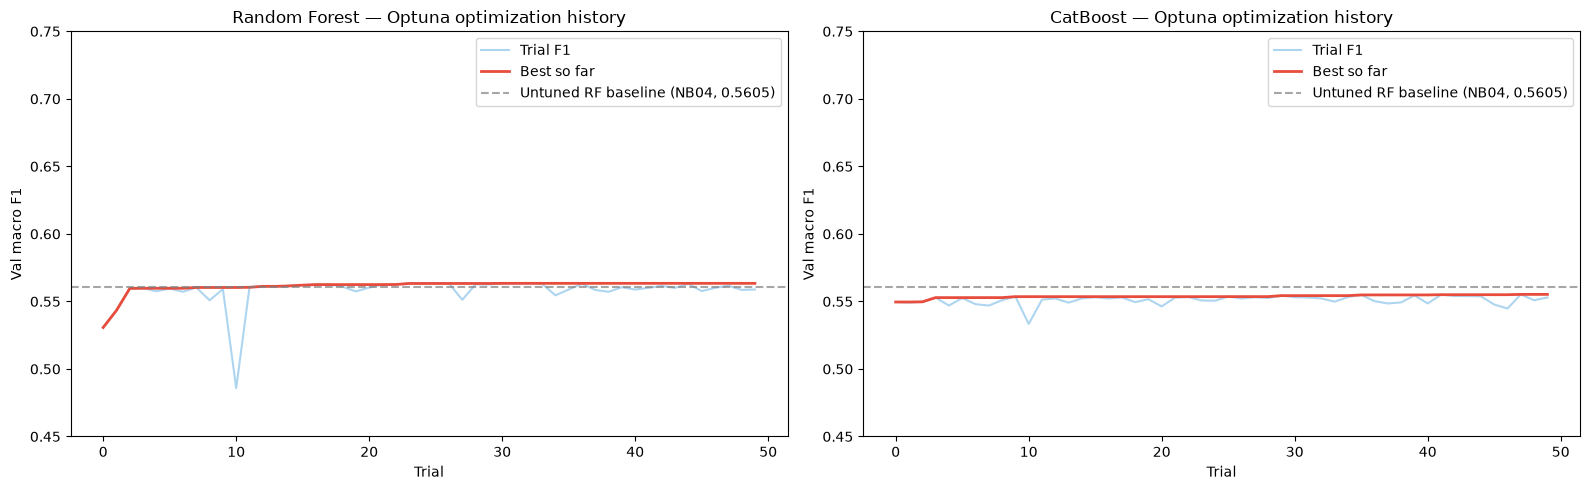

RF       — best trial: 0.5634  (Δ vs untuned NB04 baseline: +0.0029)
CatBoost — best trial: 0.5552


In [9]:
with open(MODEL_Tuning_DIR / "winner_meta.json") as f:
    nb04_meta = json.load(f)
baseline_val_f1 = nb04_meta["val_macro_f1"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, study, label in [(axes[0], study_rf, "Random Forest"),
                          (axes[1], study_cb, "CatBoost")]:
    trials_f1 = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(trials_f1)
    ax.plot(trials_f1, alpha=0.4, color="#3498db", label="Trial F1")
    ax.plot(best_so_far, color="#e74c3c", linewidth=2, label="Best so far")
    ax.axhline(y=baseline_val_f1, color="gray", linestyle="--", alpha=0.7,
               label=f"Untuned RF baseline (NB04, {baseline_val_f1:.4f})")
    ax.set_title(f"{label} — Optuna optimization history")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Val macro F1")
    ax.legend()
    ax.set_ylim(0.45, 0.75)

plt.tight_layout()
plt.savefig(OUT_DIR / "05_optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"RF       — best trial: {study_rf.best_value:.4f}  "
      f"(Δ vs untuned NB04 baseline: {study_rf.best_value-baseline_val_f1:+.4f})")
print(f"CatBoost — best trial: {study_cb.best_value:.4f}")


### Final Test & Stress Evaluation

- Evaluate the tuned winner on the **2021–2025 test set** and **2020 stress set**.
- Compare the final decision rule against default argmax predictions.
- Report **Macro F1**, **OvR Macro AUC**, and classification metrics.
- Generate confusion matrices for both test and stress evaluations.

────────────────────────────────────────────────────────────
RF Tuned — TEST 2021-2025
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.93      0.83      0.88     57811
    MODERATE       0.32      0.59      0.42      8335
        HIGH       0.38      0.36      0.37      2435

    accuracy                           0.78     68581
   macro avg       0.55      0.59      0.55     68581
weighted avg       0.84      0.78      0.80     68581

Macro F1 (final rule): 0.5545
Macro F1 (argmax):     0.5496
AUC (OvR macro):       0.8318

────────────────────────────────────────────────────────────
RF Tuned — STRESS 2020 (not used for selection)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.87      0.78      0.82     11306
    MODERATE       0.41      0.49      0.45      3737
        HIGH       0.45      0.56      0.50    

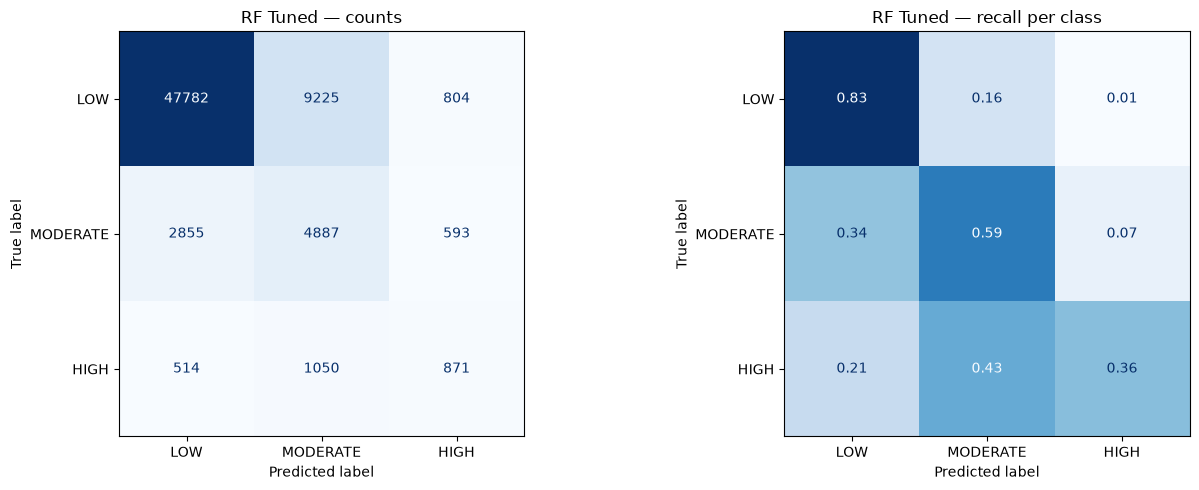

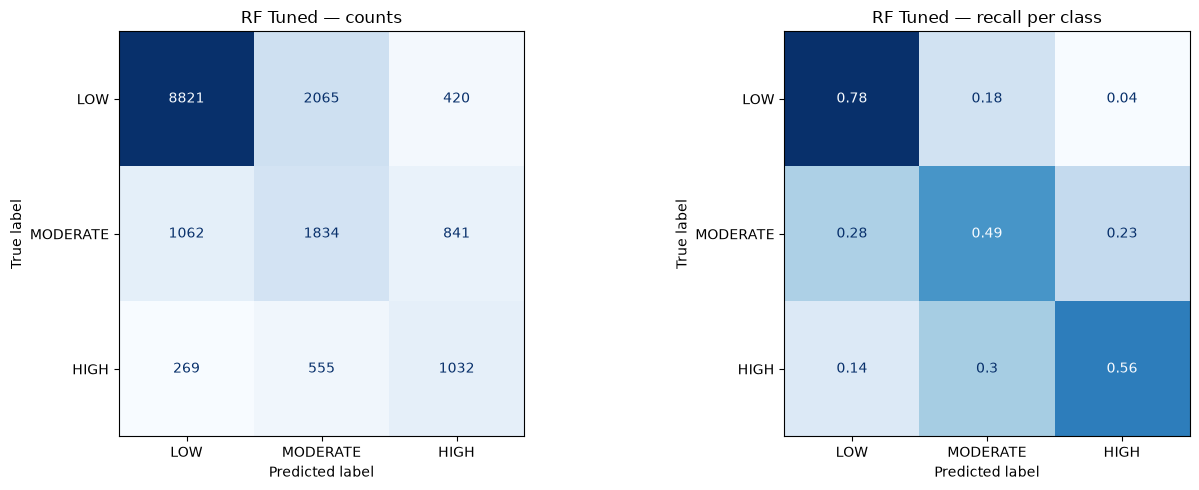

In [10]:
proba_test   = winner_tuned.predict_proba(X_w_test)
proba_stress = winner_tuned.predict_proba(X_w_stress)

preds_test_cal   = predict_final(proba_test)
preds_stress_cal = predict_final(proba_stress)

preds_test_def = winner_tuned.predict(X_w_test)
f1_test_def    = f1_score(y_test, preds_test_def, average="macro", zero_division=0)
f1_test_cal    = f1_score(y_test, preds_test_cal, average="macro", zero_division=0)
auc_test       = roc_auc_score(y_test, proba_test, multi_class="ovr", average="macro")

print(f"{'─'*60}")
print(f"{winner_name} — TEST 2021-2025")
print(f"{'─'*60}")
print(classification_report(y_test, preds_test_cal,
      target_names=[RISK_LABELS[i] for i in range(3)], zero_division=0))
print(f"Macro F1 (final rule): {f1_test_cal:.4f}")
print(f"Macro F1 (argmax):     {f1_test_def:.4f}")
print(f"AUC (OvR macro):       {auc_test:.4f}")

# Stress 2020 — report BOTH argmax and final-rule for transparency
preds_stress_def = winner_tuned.predict(X_w_stress)
f1_stress_def  = f1_score(y_stress, preds_stress_def, average="macro", zero_division=0)
f1_stress_cal  = f1_score(y_stress, preds_stress_cal, average="macro", zero_division=0)
auc_stress     = roc_auc_score(y_stress, proba_stress, multi_class="ovr", average="macro")

print(f"\n{'─'*60}")
print(f"{winner_name} — STRESS 2020 (not used for selection)")
print(f"{'─'*60}")
print(classification_report(y_stress, preds_stress_cal,
      target_names=[RISK_LABELS[i] for i in range(3)], zero_division=0))
print(f"Macro F1 (final rule): {f1_stress_cal:.4f}")
print(f"Macro F1 (argmax):     {f1_stress_def:.4f}")
print(f"AUC (OvR macro):       {auc_stress:.4f}")

plot_cm(winner_name, winner_tuned, X_w_test, y_test,
        "05_cm_test.png", preds_override=preds_test_cal)
plot_cm(winner_name, winner_tuned, X_w_stress, y_stress,
        "05_cm_stress.png", preds_override=preds_stress_cal)


In [11]:
cb_test_preds   = cb_tuned.predict(X_test).astype(int).ravel()
cb_stress_preds = cb_tuned.predict(X_stress).astype(int).ravel()

cb_test_f1     = f1_score(y_test,   cb_test_preds,   average="macro", zero_division=0)
cb_test_high   = f1_score(y_test,   cb_test_preds,   average=None,    zero_division=0)[2]
cb_stress_f1   = f1_score(y_stress, cb_stress_preds, average="macro", zero_division=0)
cb_stress_high = f1_score(y_stress, cb_stress_preds, average=None,    zero_division=0)[2]

rf_test_high   = f1_score(y_test,   preds_test_cal,   average=None, zero_division=0)[2]
rf_stress_high = f1_score(y_stress, preds_stress_cal, average=None, zero_division=0)[2]

print(f"{'Model':<25} {'Split':<10} {'MacroF1':>9} {'F1-HIGH':>9}")
print("─" * 55)
print(f"{'RF (winner)':<25} {'Test':<10} {f1_test_cal:>9.4f} {rf_test_high:>9.4f}")
print(f"{'CatBoost (runner-up)':<25} {'Test':<10} {cb_test_f1:>9.4f} {cb_test_high:>9.4f}")
print(f"{'RF (winner)':<25} {'Stress':<10} {f1_stress_cal:>9.4f} {rf_stress_high:>9.4f}")
print(f"{'CatBoost (runner-up)':<25} {'Stress':<10} {cb_stress_f1:>9.4f} {cb_stress_high:>9.4f}")


Model                     Split        MacroF1   F1-HIGH
───────────────────────────────────────────────────────
RF (winner)               Test          0.5545    0.3704
CatBoost (runner-up)      Test          0.4994    0.2685
RF (winner)               Stress        0.5891    0.4975
CatBoost (runner-up)      Stress        0.5643    0.4713


### Per-Year Test Breakdown

- Evaluate the final decision rule separately for each test year.
- Report **Macro F1**, **Balanced Accuracy**, **positive rate**, **HIGH-class F1**, and sample count.
- This shows how model performance varies across different fire seasons.

In [12]:
print(f"{winner_name} — per-year breakdown (test, final decision rule):")
print(f"  {'Year':<6} {'MacroF1':>9} {'BalAcc':>9} {'PosRate':>9} {'F1-HIGH':>9} {'N':>8}")
print(f"  {'─'*55}")

for yr in sorted(test["year"].unique()):
    mask    = test["year"] == yr
    X_yr    = test.loc[mask, WINNER_FEATURES].fillna(0)  
    y_yr    = test.loc[mask, TARGET]
    p_yr    = winner_tuned.predict_proba(X_yr)
    pred_yr = predict_final(p_yr)
    f1      = f1_score(y_yr, pred_yr, average="macro",  zero_division=0)
    bal     = balanced_accuracy_score(y_yr, pred_yr)
    f1h     = f1_score(y_yr, pred_yr, average=None,     zero_division=0)
    pos     = 100 * (y_yr > 0).mean()
    print(f"  {yr:<6} {f1:>9.4f} {bal:>9.4f} {pos:>8.1f}% "
          f"{f1h[2] if len(f1h)>2 else 0:>9.4f} {len(y_yr):>8,}")

RF Tuned — per-year breakdown (test, final decision rule):
  Year     MacroF1    BalAcc   PosRate   F1-HIGH        N
  ───────────────────────────────────────────────────────
  2021      0.5969    0.6398     19.3%    0.5277   14,244
  2022      0.5372    0.5699     18.8%    0.2830   14,169
  2023      0.5472    0.5837     14.4%    0.3636   13,598
  2024      0.4615    0.5057     10.1%    0.1395   13,072
  2025      0.4966    0.5269     15.3%    0.1699   13,498


### Feature Importance

- Extract feature importance from the tuned **Random Forest or CatBoost** model.
- Rank features and visualize the **top 25**.
- Print the **top 15** most important features.

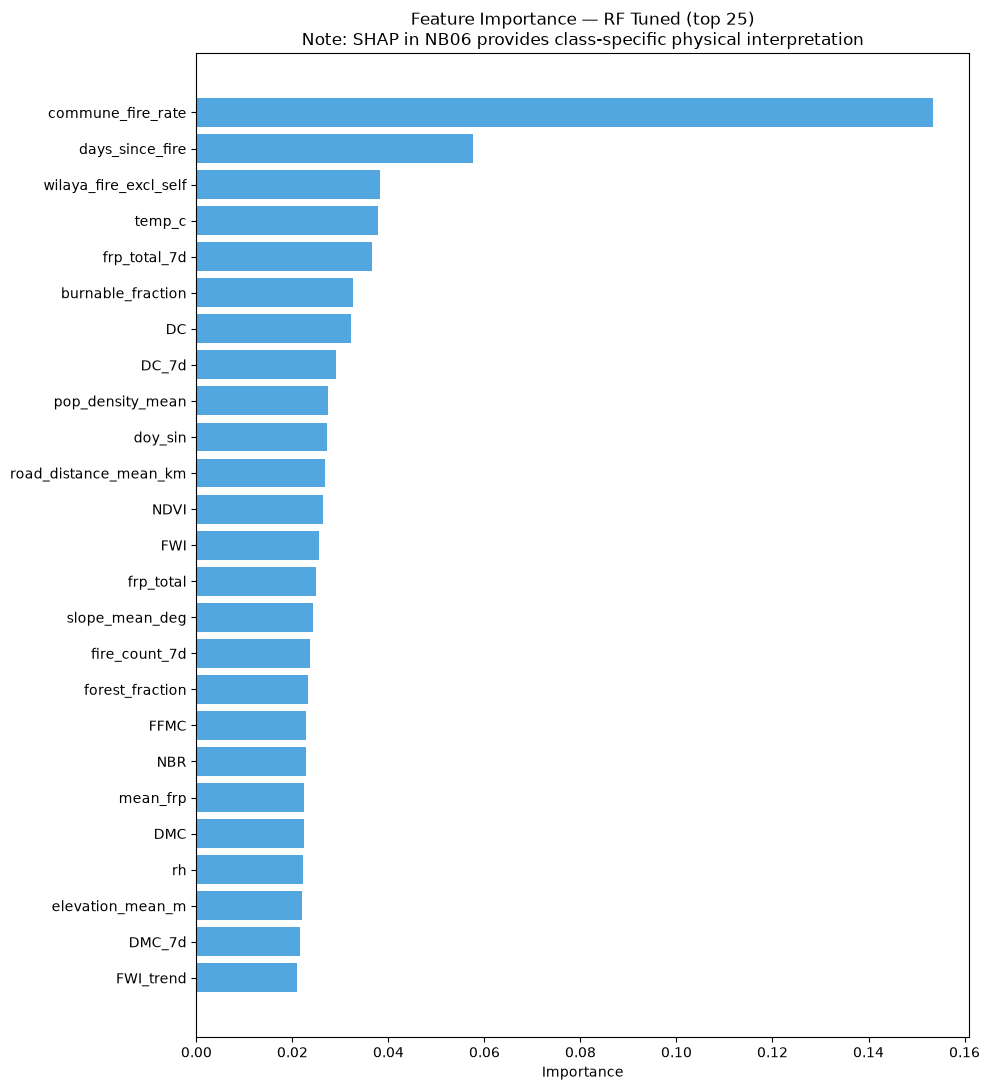


Top 15 features:
              feature  importance
    commune_fire_rate    0.153332
      days_since_fire    0.057622
wilaya_fire_excl_self    0.038258
               temp_c    0.037736
         frp_total_7d    0.036506
    burnable_fraction    0.032709
                   DC    0.032177
                DC_7d    0.029093
     pop_density_mean    0.027468
              doy_sin    0.027140
road_distance_mean_km    0.026835
                 NDVI    0.026330
                  FWI    0.025468
            frp_total    0.024922
       slope_mean_deg    0.024371


In [13]:
fig, ax = plt.subplots(figsize=(10, 11))

if isinstance(winner_tuned, RandomForestClassifier):
    imp  = winner_tuned.feature_importances_
elif isinstance(winner_tuned, CatBoostClassifier):
    imp  = winner_tuned.get_feature_importance()
else:
    imp  = None

if imp is not None:
    imp_df = (pd.DataFrame({"feature": FEATURES, "importance": imp})
              .sort_values("importance", ascending=False)
              .reset_index(drop=True))
    ax.barh(imp_df["feature"][:25][::-1], imp_df["importance"][:25][::-1],
            color="#3498db", alpha=0.85)
    ax.set_title(f"Feature Importance — {winner_name} (top 25)\n"
                 "Note: SHAP in NB06 provides class-specific physical interpretation")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "05_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nTop 15 features:")
    print(imp_df.head(15)[["feature", "importance"]].to_string(index=False))

In [14]:
joblib.dump(rf_tuned,  MODEL_Tuning_DIR / "rf_tuned.pkl")
cb_tuned.save_model(str(MODEL_Tuning_DIR / "cb_tuned.cbm"))
print("Saved rf_tuned.pkl and cb_tuned.cbm")

joblib.dump(winner_tuned,
    MODEL_Tuning_DIR / ("winner_tuned.pkl" if isinstance(winner_tuned, RandomForestClassifier)
                else "winner_tuned.cbm"))
print(f"Saved winner: {winner_name}")

tuning_meta = {
    "winner_model":          winner_name,
    "features":              WINNER_FEATURES,
    "rf_best_params":        study_rf.best_params,
    "rf_best_val_f1":        round(study_rf.best_value, 4),
    "cb_best_params":        study_cb.best_params,
    "cb_best_val_f1":        round(study_cb.best_value, 4),
    "cb_test_macro_f1":      round(cb_test_f1, 4),
    "cb_stress_macro_f1":    round(cb_stress_f1, 4),
    "calibration_applied":   mod_t is not None,
    "calibration_mod_thresh":mod_t,
    "calibration_high_thresh":high_t,
    "val_macro_f1_final":       round(best_f1_thresh, 4),
    "test_macro_f1_default":    round(f1_test_def,  4),
    "test_macro_f1_final":      round(f1_test_cal,  4),
    "test_auc_ovr":             round(auc_test,      4),
    "stress_macro_f1_default":  round(f1_stress_def, 4),
    "stress_macro_f1_final":    round(f1_stress_cal,4),
    "stress_auc_ovr":            round(auc_stress,    4),
    "train_years":  meta["train_years"],
    "val_years":    meta["validation_years"],
    "test_years":   meta["test_years"],
    "stress_years": meta["stress_years"],
    "n_features":   len(WINNER_FEATURES),
}
with open(MODEL_Tuning_DIR / "tuning_meta.json", "w") as f:
    json.dump(tuning_meta, f, indent=2)
print("Saved tuning_meta.json")

Saved rf_tuned.pkl and cb_tuned.cbm
Saved winner: RF Tuned
Saved tuning_meta.json
